# Palm Image Dataset — Exploratory Data Analysis


## 1. Introduction

This notebook explores the palm/hand image dataset that will power the **Palm Analysis Engine** of the Palmistry & Tarot Intelligence Platform.

**Goals of this EDA:**
- Understand the metadata in `HandInfo.csv`.
- Get a basic summary of the image dataset (`Hands/`).
- Visually inspect a few sample images.
- Check typical image resolution.
- Take a first look at hand landmark detection using **MediaPipe**, which will later be used to extract palm features (lines, shape, finger structure).


## 2. Import Libraries

In [6]:
import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## 3. Dataset Loading

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
CSV_PATH = "/content/HandInfo.csv"
IMAGES_DIR = "/content/drive/MyDrive/infosys internship/Hands"

df = pd.read_csv(CSV_PATH)
print(f"Loaded CSV with shape: {df.shape}")


Loaded CSV with shape: (11076, 9)


## 4. HandInfo.csv Overview

In [9]:
df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [10]:
print(f"Shape (rows, columns): {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape (rows, columns): (11076, 9)
Columns: ['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish', 'aspectOfHand', 'imageName', 'irregularities']


In [11]:
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else print("No missing values in HandInfo.csv")

No missing values in HandInfo.csv


In [12]:
n_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_duplicates}")

Number of fully duplicated rows: 0


In [13]:
# Statistical summary of numerical columns
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
id,11076.0,203104.278169,1.086731e+06,0.0,576.0,1050.0,1539.25,9000000.0
age,11076.0,22.494583,6.918974e+00,18.0,21.0,21.0,22.00,75.0
accessories,11076.0,0.289906,4.537391e-01,0.0,0.0,0.0,1.00,1.0
nailPolish,11076.0,0.096334,2.950626e-01,0.0,0.0,0.0,0.00,1.0
irregularities,11076.0,0.014807,1.207844e-01,0.0,0.0,0.0,0.00,1.0


In [14]:
# Statistical summary of categorical / object columns
df.describe(include=["object"]).T

,count,unique,top,freq
gender,11076,2,female,7109
skinColor,11076,4,medium,6495
aspectOfHand,11076,4,dorsal right,2892
imageName,11076,11076,Hand_0011744.jpg,1


In [15]:
# Unique value counts for every column
unique_counts = df.nunique().sort_values(ascending=False).to_frame(name="unique_values")
unique_counts

,unique_values
imageName,11076
id,189
age,18
aspectOfHand,4
skinColor,4
accessories,2
gender,2
nailPolish,2
irregularities,2


In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n── Frequency table: {col} ──")
    display(df[col].value_counts().head(15).to_frame(name="count"))


── Frequency table: gender ──


,count
gender,
female,7109
male,3967



── Frequency table: skinColor ──


,count
skinColor,
medium,6495
fair,3493
dark,758
very fair,330



── Frequency table: aspectOfHand ──


,count
aspectOfHand,
dorsal right,2892
palmar right,2813
dorsal left,2788
palmar left,2583



── Frequency table: imageName ──


,count
imageName,
Hand_0011744.jpg,1
Hand_0000002.jpg,1
Hand_0000003.jpg,1
Hand_0000004.jpg,1
Hand_0011726.jpg,1
Hand_0011725.jpg,1
Hand_0011724.jpg,1
Hand_0011723.jpg,1
Hand_0011722.jpg,1


## 5. Basic Image Dataset Summary

In [17]:
image_paths = (
    glob.glob(os.path.join(IMAGES_DIR, "*.jpg")) +
    glob.glob(os.path.join(IMAGES_DIR, "*.jpeg")) +
    glob.glob(os.path.join(IMAGES_DIR, "*.png"))
)
print(f"Total images in Hands/: {len(image_paths)}")

class_col = "gender" if "gender" in df.columns else df.select_dtypes(include="object").columns[0]
class_counts = df[class_col].value_counts()

print(f"\nUsing '{class_col}' as class label")
print(f"Number of classes: {df[class_col].nunique()}")
print("\nImages per class:")
print(class_counts)


Total images in Hands/: 11103

Using 'gender' as class label
Number of classes: 2

Images per class:
gender
female    7109
male      3967
Name: count, dtype: int64


## 6. Sample Images

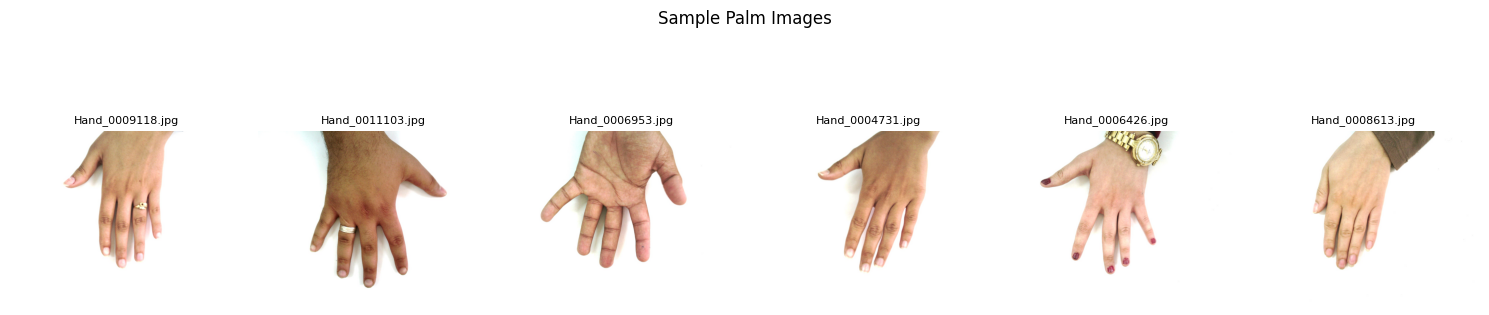

In [18]:
sample_paths = random.sample(image_paths, min(6, len(image_paths)))

fig, axes = plt.subplots(1, len(sample_paths), figsize=(15, 4))
if len(sample_paths) == 1:
    axes = [axes]
for ax, path in zip(axes, sample_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(os.path.basename(path), fontsize=8)
    ax.axis("off")
plt.suptitle("Sample Palm Images")
plt.tight_layout()
plt.show()

## 7. Basic Image Resolution Statistics

In [19]:
SAMPLE_SIZE = min(20, len(image_paths))
sample_for_res = random.sample(image_paths, SAMPLE_SIZE)

widths, heights = [], []
for path in sample_for_res:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Sampled {SAMPLE_SIZE} images")
print(f"Width  -> min: {min(widths)}, max: {max(widths)}, avg: {np.mean(widths):.0f}")
print(f"Height -> min: {min(heights)}, max: {max(heights)}, avg: {np.mean(heights):.0f}")


Sampled 20 images
Width  -> min: 1600, max: 1600, avg: 1600
Height -> min: 1200, max: 1200, avg: 1200


### 8. Dataset Quality Improvement

In [20]:
print(f"Before filtering: {len(df)} records")
print(df["aspectOfHand"].value_counts())

df_front = df[df["aspectOfHand"].str.contains("palmar", case=False, na=False)].copy()
print(f"\nAfter keeping only palmar (front) images: {len(df_front)} records")

front_image_names = set(df_front["imageName"])
image_paths_front = [p for p in image_paths if os.path.basename(p) in front_image_names]
print(f"Front-side images found on disk: {len(image_paths_front)}")

Before filtering: 11076 records
aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64

After keeping only palmar (front) images: 5396 records
Front-side images found on disk: 5396


In [21]:
print("── Dataset Cleaning Summary ──")
print(f"Original total images:        {len(image_paths)}")
print(f"After removing back-of-hand:  {len(image_paths_front)}")

final_image_names = set(os.path.basename(p) for p in image_paths_front)
df_clean = df_front[df_front["imageName"].isin(final_image_names)].copy()

print(f"Final usable images (after removing back-of-hand): {len(final_image_names)}")
print(f"\nCleaned metadata shape: {df_clean.shape}")
df_clean.head()

── Dataset Cleaning Summary ──
Original total images:        11103
After removing back-of-hand:  5396
Final usable images (after removing back-of-hand): 5396

Cleaned metadata shape: (5396, 9)


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
30,0,27,male,fair,1,0,palmar left,Hand_0000038.jpg,0
31,0,27,male,fair,1,0,palmar left,Hand_0000039.jpg,0
32,0,27,male,fair,1,0,palmar left,Hand_0000040.jpg,0
33,0,27,male,fair,1,0,palmar left,Hand_0000041.jpg,0
34,0,27,male,fair,1,0,palmar left,Hand_0000042.jpg,0


# MediaPipe Hand Landmark Detection


In [28]:
import cv2
import mediapipe as mp

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

In [26]:
selected_image_name = random.choice(list(final_image_names))
sample_image_path = os.path.join(IMAGES_DIR, selected_image_name)
print(f"Selected image: {sample_image_path}")

image_bgr = cv2.imread(sample_image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

Selected image: /content/drive/MyDrive/infosys internship/Hands/Hand_0004406.jpg


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


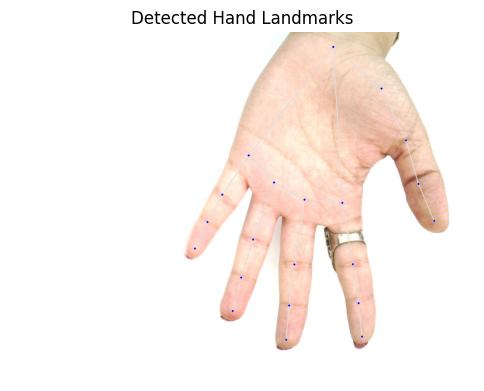

In [29]:
landmarks_df = None

with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
    result = hands.process(image_rgb)

    annotated_image = image_rgb.copy()
    hand_landmarks = result.multi_hand_landmarks[0]

    mp_drawing.draw_landmarks(
        annotated_image,
        hand_landmarks,
        mp_hands.HAND_CONNECTIONS
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(annotated_image)
    plt.title("Detected Hand Landmarks")
    plt.axis("off")
    plt.show()

    landmarks_df = pd.DataFrame(
        [(i, lm.x, lm.y, lm.z) for i, lm in enumerate(hand_landmarks.landmark)],
        columns=["landmark_id", "x", "y", "z"]
    )

In [30]:
if landmarks_df is not None:
    display(landmarks_df)


,landmark_id,x,y,z
0,0,0.695547,0.042936,4.459769e-07
1,1,0.798864,0.162214,-5.347827e-02
2,2,0.851546,0.310706,-7.967218e-02
3,3,0.878439,0.435626,-1.022720e-01
4,4,0.911992,0.541169,-1.248079e-01
5,5,0.714877,0.489677,-3.548573e-02
6,6,0.736900,0.665448,-7.479561e-02
7,7,0.749849,0.777096,-1.108775e-01
8,8,0.757296,0.873252,-1.383446e-01
9,9,0.633132,0.480373,-4.112105e-02
